In [1]:
import matplotlib.pyplot as plt

from imagematerials.rest_of.metals_projections import (
    steel_projection, 
    aluminium_projection, 
    copper_projection)

from imagematerials.rest_of.preprocessing.regressions_all_materials import *

from imagematerials.rest_of.water import water_consumption

from imagematerials.rest_of.biomass import biomass_data

from imagematerials.rest_of.fossil_fuels import fossil_fuel_data

from imagematerials.rest_of.nmm_projections import (cement_projection, 
                                                    sand_projections, 
                                                    limestone_projection,
                                                    clay_projections) 

from pathlib import Path

from imagematerials.rest_of.preprocessing.main import read_gompertz_values


In [2]:
results = fit_models_all_materials()
gompertz = make_gompertz_coefs_da(results)
mean_historic_other_fraction_consumption_to_xr(results)
all_historic_data_xr = historic_other_fraction_consumption_to_xr(results)


SSP2_M_CP
low_steady assigned to class_ 4
low_steady assigned to class_ 5
low_steady assigned to class_ 6
low_steady assigned to class_ 7
low_steady assigned to class_ 8
low_steady assigned to class_ 9
low_steady assigned to class_ 14
low_steady assigned to class_ 17
low_steady assigned to class_ 18
low_steady assigned to class_ 21
low_steady assigned to class_ 22
low_steady assigned to class_ 24
low_steady assigned to class_ 25
low_steady assigned to class_ 26
low assigned to class_ 8
low assigned to class_ 10
low assigned to class_ 26
low assigned to class_ 4
low assigned to class_ 5
low assigned to class_ 6
all_regions assigned to class_ 24
all_regions assigned to class_ 23
steel
cement
limestone
clay
sand
copper
aluminium


In [3]:
gompertz_values = read_gompertz_values(base_directory=Path("C:/Coding/image-materials/data/raw/"), scenario = "SSP2_VLLO_LifeTech")

gompertz scaling applied for scenario: SSP2_VLLO_LifeTech


In [4]:

# for every material in gompertz_values get the lowest value of 'a' and print it
# if there is a np.nan ignore it at take the next lowest value

# also print the region and the highest value of a
import numpy as np

for material in gompertz_values.coords['material'].values:
    a_values = gompertz_values.sel(coef='a', material=material).values
    a_values = a_values[~np.isnan(a_values)]
    if len(a_values) > 0:
        min_a = np.min(a_values)
        max_a = np.max(a_values)
        print(f"Material: {material}, Min a: {min_a}, Max a: {max_a}")
    else:
        print(f"Material: {material}, Min a: NaN")

Material: Aluminium, Min a: 0.0012892800138711977, Max a: 0.025662739197629077
Material: Cement, Min a: 0.145456431456701, Max a: 1.5986336750326786
Material: Clay, Min a: 0.2210924651257886, Max a: 2.656422207014211
Material: Copper, Min a: 0.0032553948455217303, Max a: 0.012144119103472493
Material: Limestone, Min a: 0.3450388174158378, Max a: 2.9948760603783406
Material: Sand, Min a: 3.856715966342671, Max a: 9.999999999980812
Material: Steel, Min a: 0.09882881366833557, Max a: 0.514414525688476


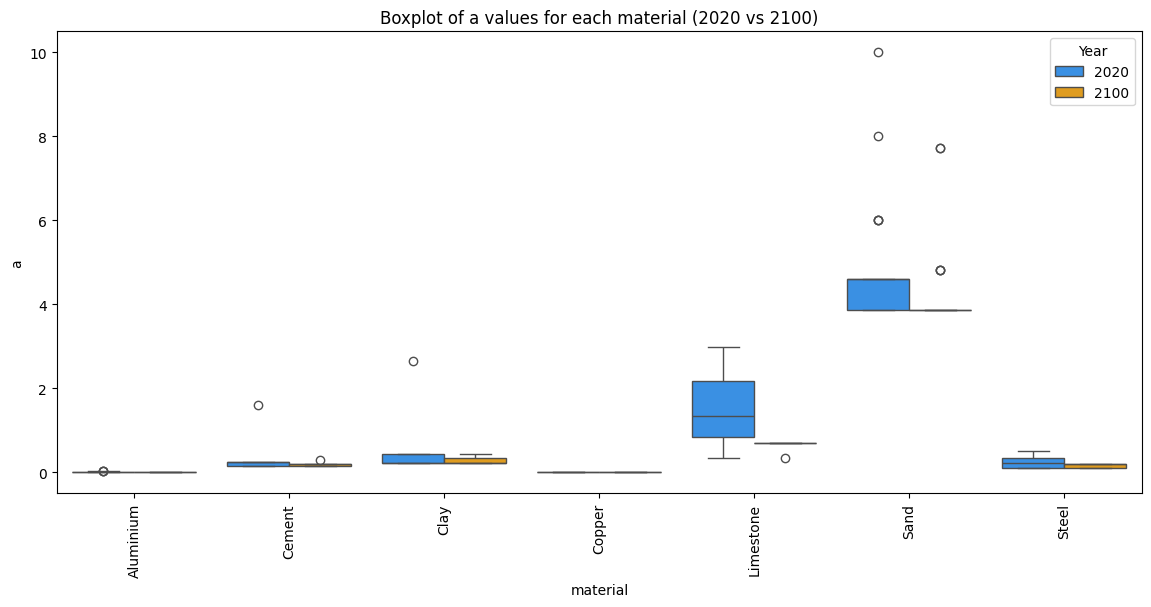

In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

a_data = []
for material in gompertz_values.coords['material'].values:
    # 2020 values
    a_2020 = gompertz_values.sel(coef='a', material=material, Time=2020).values
    regions_2020 = gompertz_values.sel(coef='a', material=material, Time=2020).coords['Region'].values
    for a, region in zip(a_2020, regions_2020):
        if not np.isnan(a):
            a_data.append({'material': material, 'a': a, 'Region': region, 'Year': 2020})
    # 2100 values
    a_2100 = gompertz_values.sel(coef='a', material=material, Time=2100).values
    regions_2100 = gompertz_values.sel(coef='a', material=material, Time=2100).coords['Region'].values
    for a, region in zip(a_2100, regions_2100):
        if not np.isnan(a):
            a_data.append({'material': material, 'a': a, 'Region': region, 'Year': 2100})

a_df = pd.DataFrame(a_data)
plt.figure(figsize=(14, 6))
sns.boxplot(x='material', y='a', hue='Year', data=a_df, palette={2020: "dodgerblue", 2100: "orange"})
plt.xticks(rotation=90)
plt.title('Boxplot of a values for each material (2020 vs 2100)')
plt.show()

In [6]:
# # adapt a of gompertz in the following way: 
# # - the regions with the lowest a stay at their a value
# # - all other regions reduce their a value linearly towards the 2x lowest a value. 
# # - if this is not possible because that value is higher than their a value, they reduce it to the next lowest a value
# # - replace the a value in gompertz with the new a value starting from 2030 to reach in 2100 the new a value

# import numpy as np

# years = gompertz.coords['Time'].values
# for material in gompertz.coords['material'].values:
#     a_2030 = gompertz.sel(coef='a', material=material, Time=2030).values
#     regions = gompertz.coords['Region'].values
#     valid = ~np.isnan(a_2030)
#     sorted_a = np.sort(a_2030[valid])
#     lowest_a = sorted_a[0]
#     target_a = 2 * lowest_a

#     for i, region in enumerate(regions):
#         current_a_2030 = a_2030[i]
#         if np.isnan(current_a_2030):
#             continue
#         # Lowest region stays at its value
#         if current_a_2030 == lowest_a:
#             continue
#         # If current value is lower than 2x lowest, reduce by 20%, but not below lowest_a
#         if current_a_2030 < target_a:
#             reduce_target = max(current_a_2030 * 0.8, lowest_a)
#             for year in years:
#                 if year < 2030:
#                     continue
#                 elif year >= 2030 and year <= 2100:
#                     frac = (year - 2030) / (2100 - 2030)
#                     new_a = current_a_2030 + frac * (reduce_target - current_a_2030)
#                     new_a = max(new_a, lowest_a)
#                     gompertz.loc[dict(coef='a', material=material, Region=region, Time=year)] = new_a
#                 elif year > 2100:
#                     gompertz.loc[dict(coef='a', material=material, Region=region, Time=year)] = reduce_target
#         # Otherwise, reduce to 2x lowest value, but not below lowest_a
#         else:
#             for year in years:
#                 if year < 2030:
#                     continue
#                 elif year >= 2030 and year <= 2100:
#                     frac = (year - 2030) / (2100 - 2030)
#                     new_a = current_a_2030 + frac * (target_a - current_a_2030)
#                     new_a = max(new_a, lowest_a)
#                     gompertz.loc[dict(coef='a', material=material, Region=region, Time=year)] = new_a
#                 elif year > 2100:
#                     gompertz.loc[dict(coef='a', material=material, Region=region, Time=year)] = max(target_a, lowest_a)

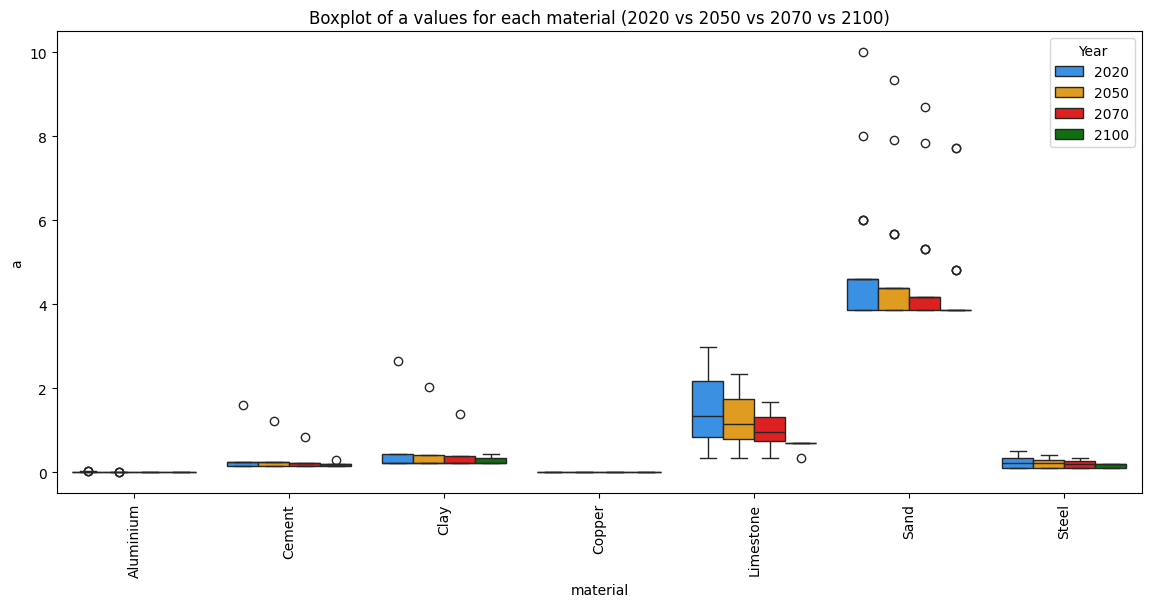

In [7]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

a_data = []
for material in gompertz_values.coords['material'].values:
    # 2020 values
    a_2020 = gompertz_values.sel(coef='a', material=material, Time=2020).values
    regions_2020 = gompertz_values.sel(coef='a', material=material, Time=2020).coords['Region'].values
    for a, region in zip(a_2020, regions_2020):
        if not np.isnan(a):
            a_data.append({'material': material, 'a': a, 'Region': region, 'Year': 2020})
    # 2050 values
    a_2050 = gompertz_values.sel(coef='a', material=material, Time=2050).values
    regions_2050 = gompertz_values.sel(coef='a', material=material, Time=2050).coords['Region'].values
    for a, region in zip(a_2050, regions_2050):
        if not np.isnan(a):
            a_data.append({'material': material, 'a': a, 'Region': region, 'Year': 2050})
    # 2070 values
    a_2070 = gompertz_values.sel(coef='a', material=material, Time=2070).values
    regions_2070 = gompertz_values.sel(coef='a', material=material, Time=2070).coords['Region'].values
    for a, region in zip(a_2070, regions_2070):
        if not np.isnan(a):
            a_data.append({'material': material, 'a': a, 'Region': region, 'Year': 2070})
    # 2100 values
    a_2100 = gompertz_values.sel(coef='a', material=material, Time=2100).values
    regions_2100 = gompertz_values.sel(coef='a', material=material, Time=2100).coords['Region'].values
    for a, region in zip(a_2100, regions_2100):
        if not np.isnan(a):
            a_data.append({'material': material, 'a': a, 'Region': region, 'Year': 2100})

a_df = pd.DataFrame(a_data)
plt.figure(figsize=(14, 6))
sns.boxplot(x='material', y='a', hue='Year', data=a_df, palette={2020: "dodgerblue", 
                                                                 2050: "orange", 
                                                                 2070: "red", 
                                                                 2100: "green"})
plt.xticks(rotation=90)
plt.title('Boxplot of a values for each material (2020 vs 2050 vs 2070 vs 2100)')
plt.show()

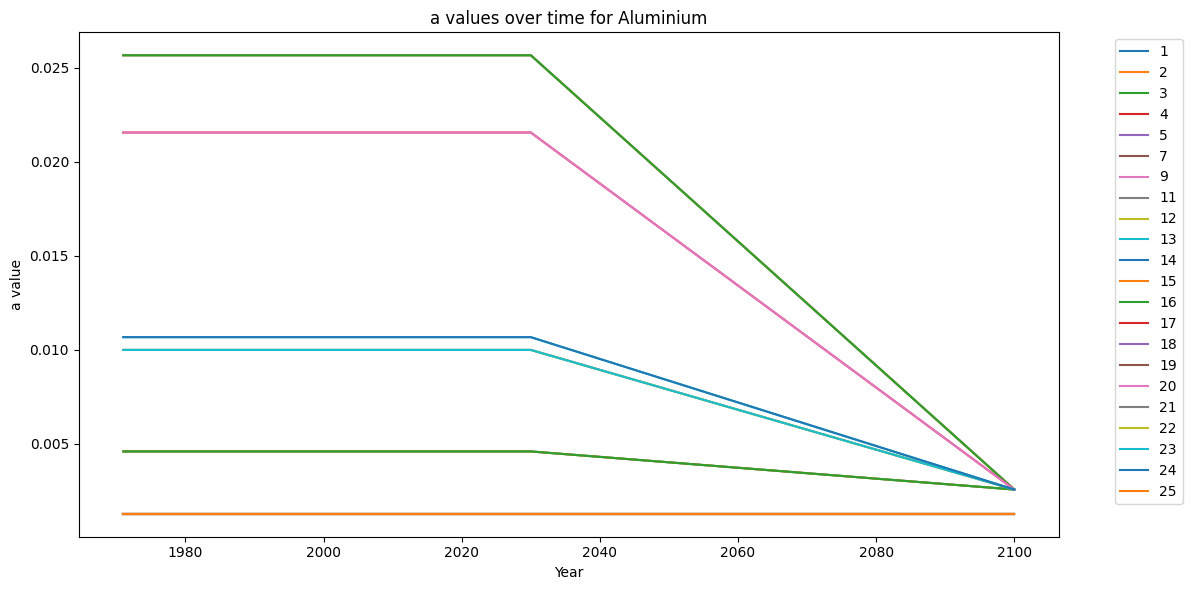

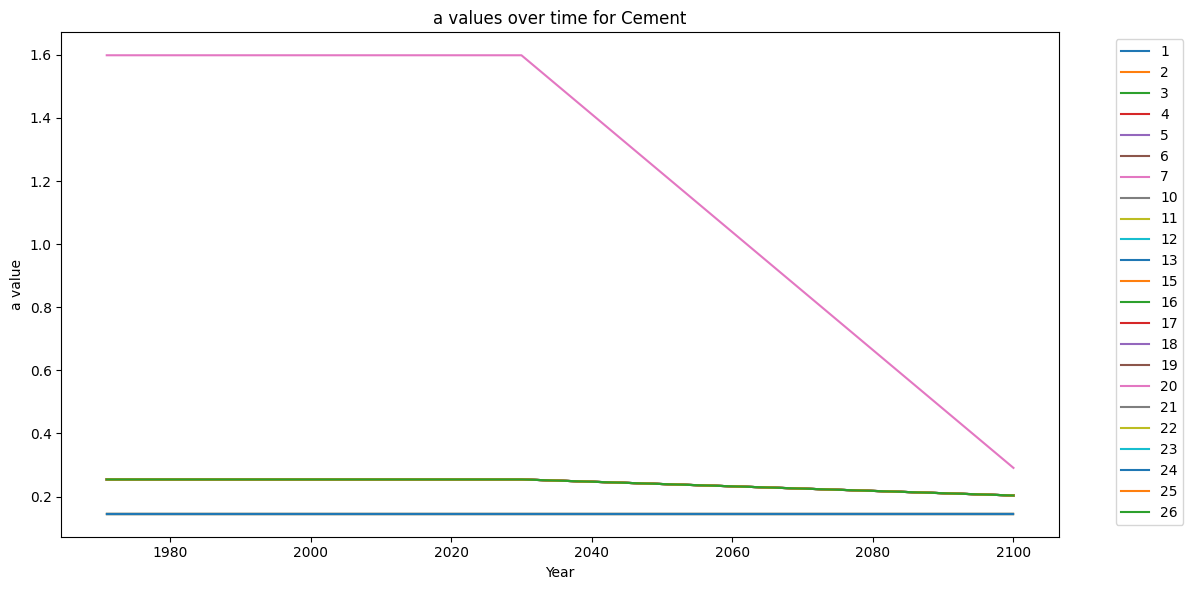

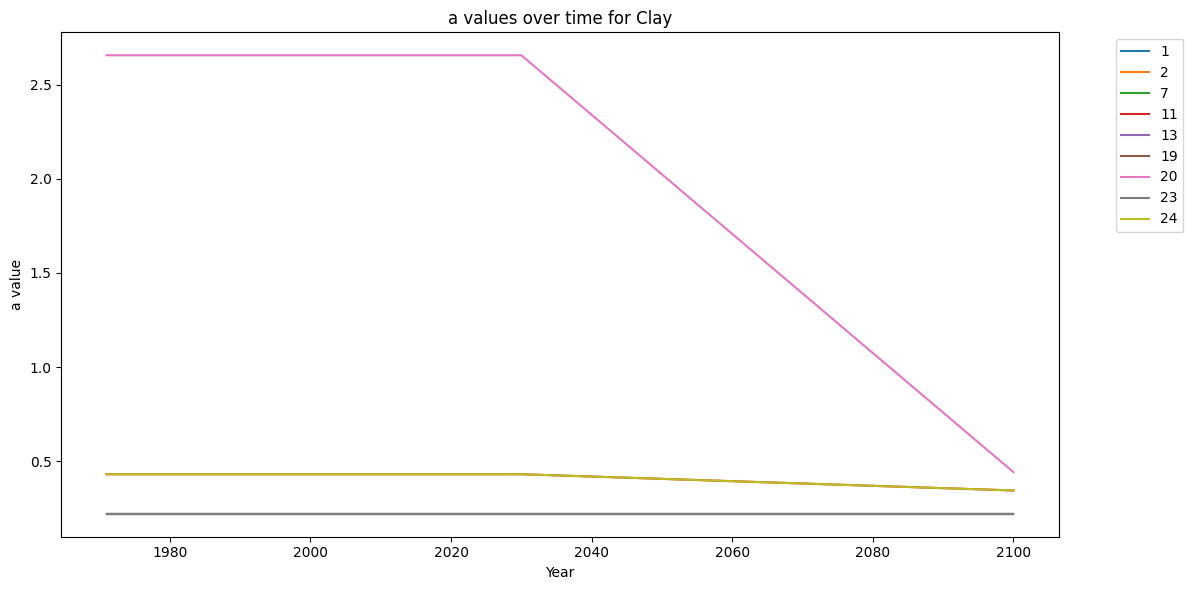

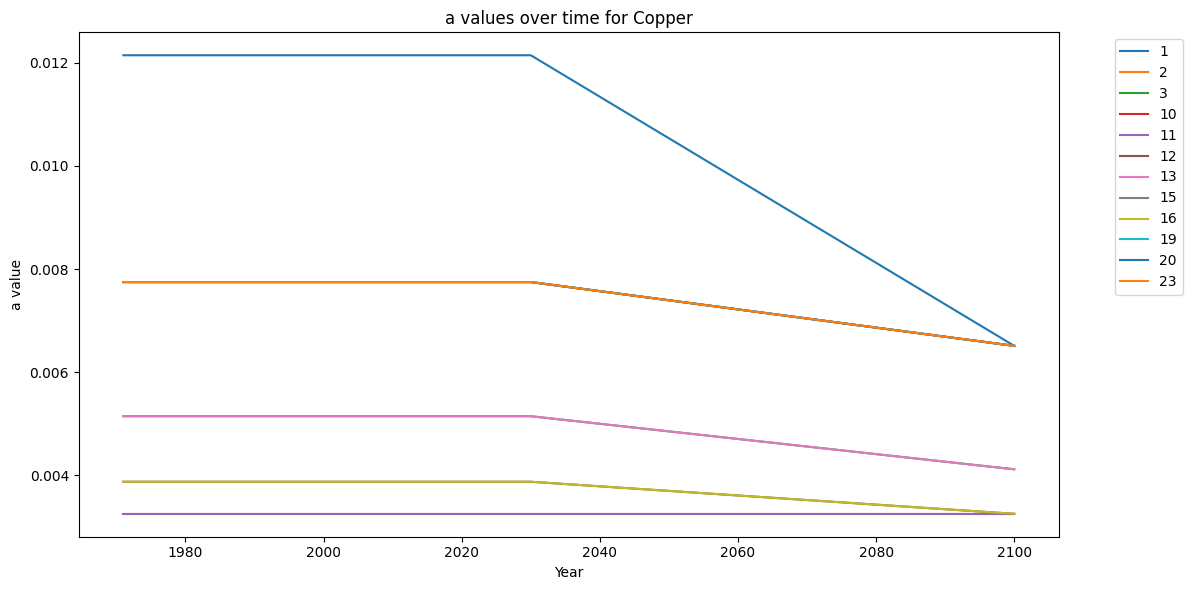

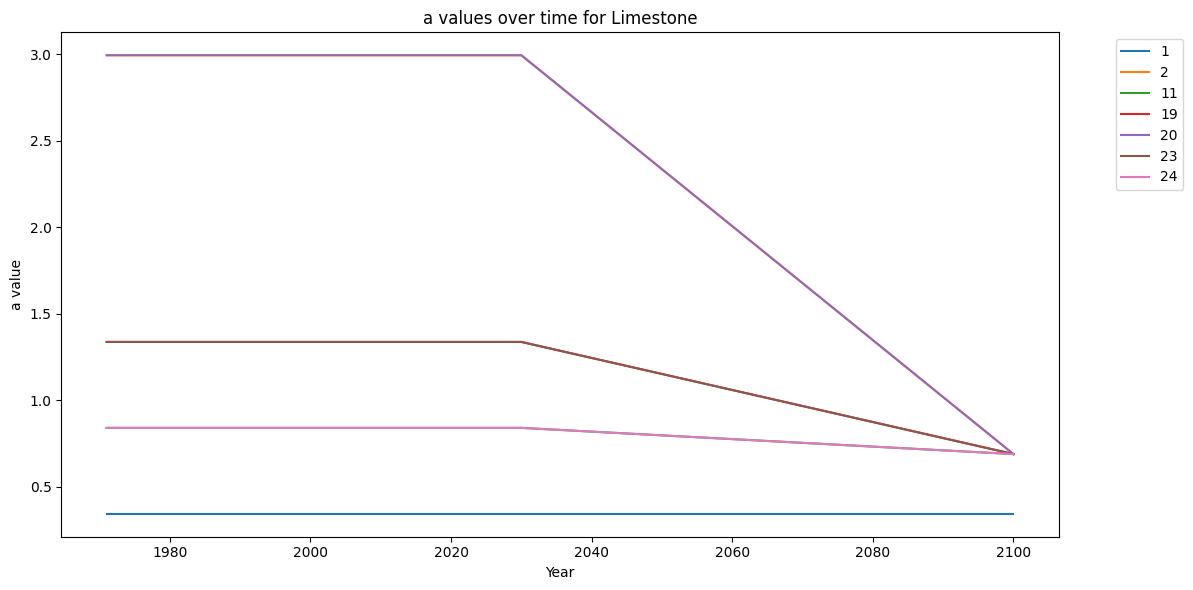

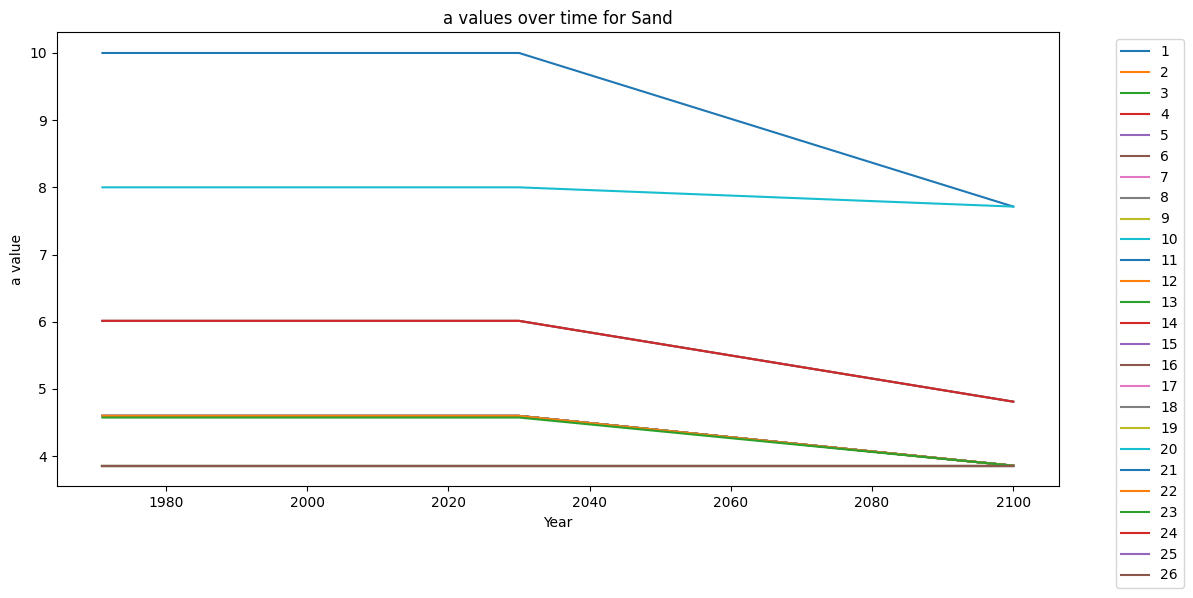

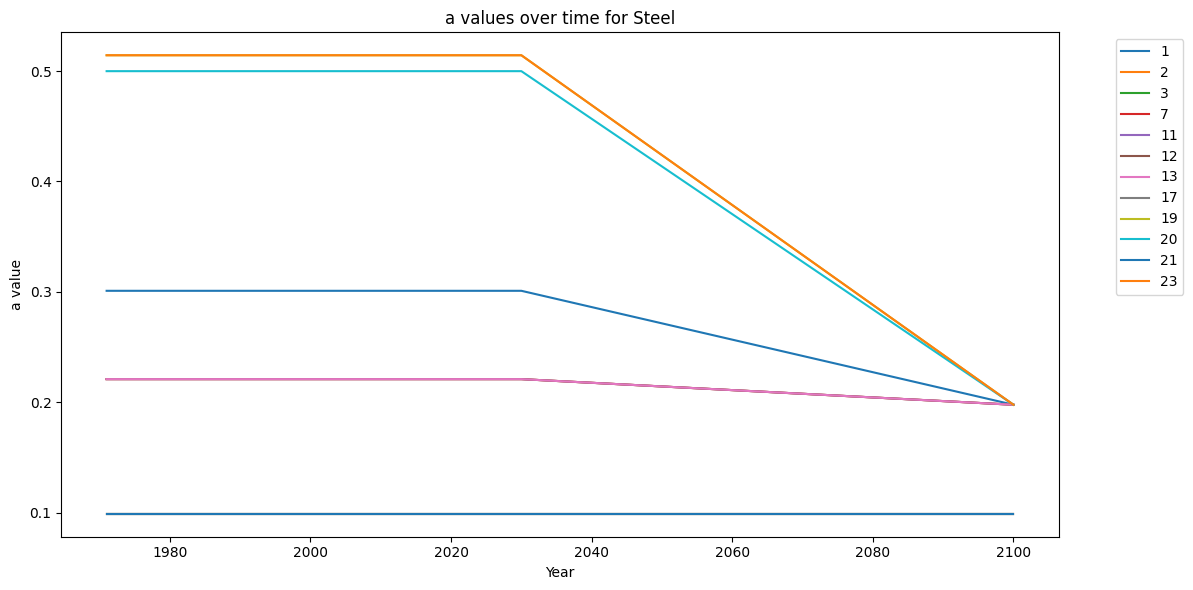

In [8]:
# plot a per region over years for all maetrials in single axes
for material in gompertz_values.coords['material'].values:
    plt.figure(figsize=(12, 6))
    for region in gompertz_values.coords['Region'].values:
        a_values = gompertz_values.sel(coef='a', material=material, Region=region).values
        if a_values.size == 0 or np.all(np.isnan(a_values)):
            continue
        plt.plot(gompertz_values.coords['Time'].values, a_values, label=region)
    plt.title(f"a values over time for {material}")
    plt.xlabel("Year")
    plt.ylabel("a value")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()